## Trainable Pic Activation

The framework includes a novel **trainable Pic activation function** with learnable parameters:


- **Trainable θ parameter**: Peak position learns optimal location (θ ∈ (0,1))
- **Controllable smoothness**: γ ∈ [0,1] controls differentiability (0=sharp, 1=smooth)
- **Bounded output**: Maps [0,1] → [0,1] with pic(0)=pic(1)=0, pic(θ)=1
- **Adaptive behavior**: Each neuron can learn its optimal activation pattern



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from Helpers.Helpers import gradient_check_layer
from Layers.Activations import Pic, ReLU
from Layers.FullyConnected import FullyConnected
from Layers.Initializers import He, Zero
from Helpers.NeuralNetwork import NeuralNetwork
from Optimization.Optimizers import Adam
from Optimization.Loss import L2Loss

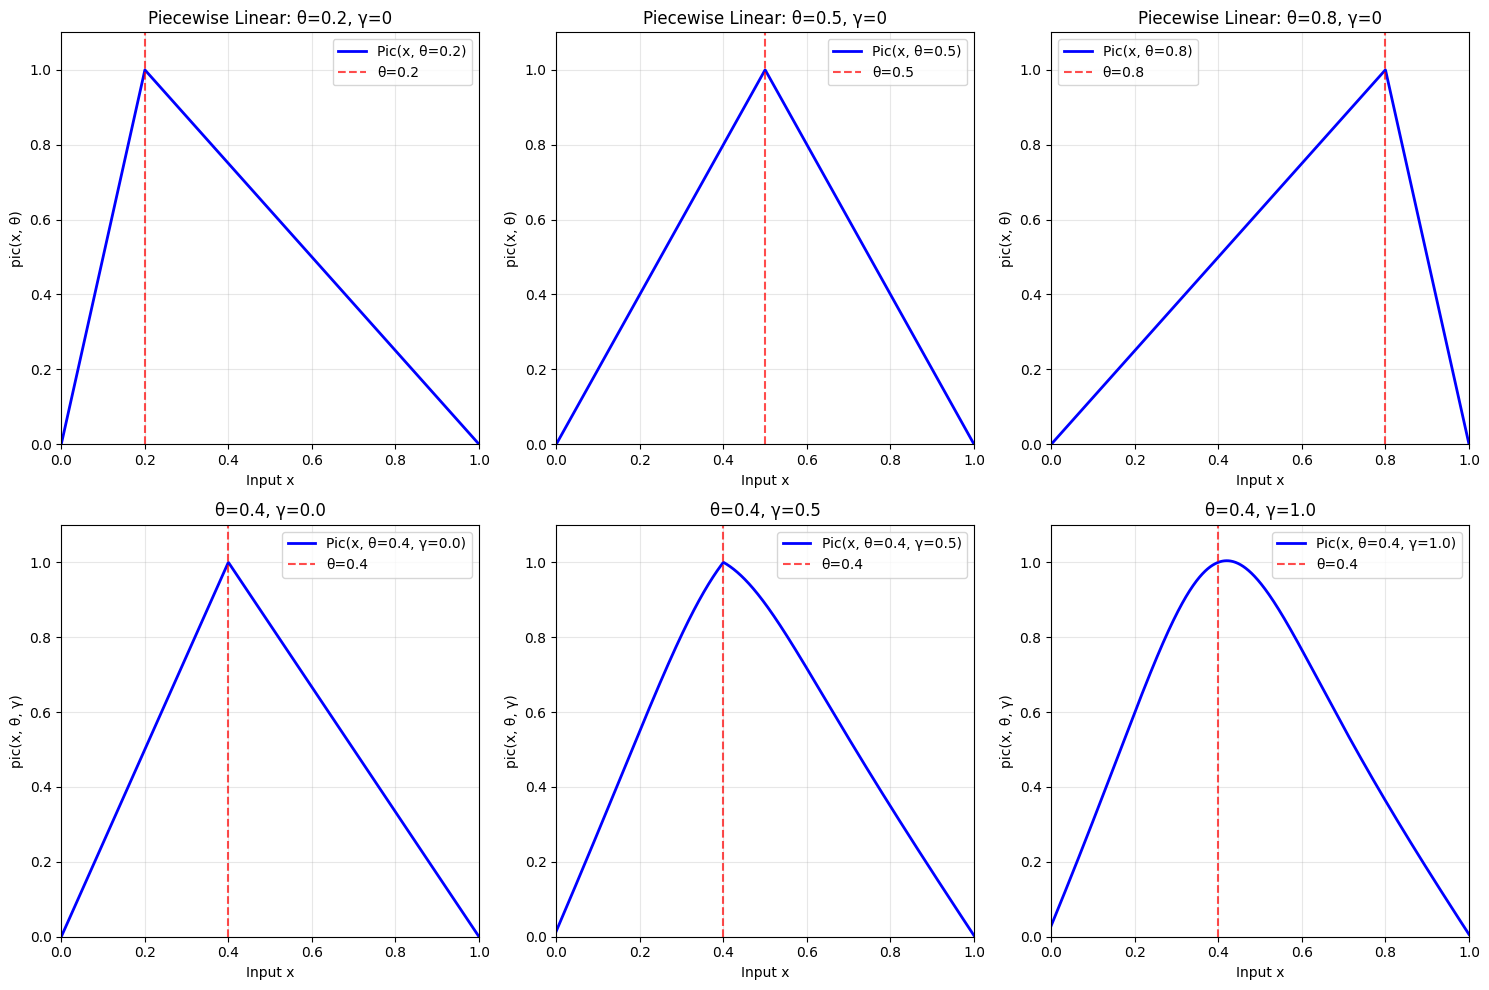

In [11]:
# Create input data in [0, 1]
x = np.linspace(0, 1, 1000).reshape(-1, 1)

# Test different theta values and gamma values
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Test different theta values with gamma=0 (piecewise linear)
theta_values = [0.2, 0.5, 0.8]
for i, theta in enumerate(theta_values):
    pic_layer = Pic(theta_init=theta, gamma=0.0)
    y = pic_layer.forward(x)
    
    axes[0, i].plot(x.flatten(), y.flatten(), 'b-', linewidth=2, label=f'Pic(x, θ={theta})')
    axes[0, i].axvline(x=theta, color='r', linestyle='--', alpha=0.7, label=f'θ={theta}')
    axes[0, i].set_title(f'Piecewise Linear: θ={theta}, γ=0')
    axes[0, i].set_xlabel('Input x')
    axes[0, i].set_ylabel('pic(x, θ)')
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].legend()
    axes[0, i].set_xlim(0, 1)
    axes[0, i].set_ylim(0, 1.1)

# Test different gamma values with fixed theta=0.4
gamma_values = [0.0, 0.5, 1.0]
theta_fixed = 0.4
for i, gamma in enumerate(gamma_values):
    pic_layer = Pic(theta_init=theta_fixed, gamma=gamma)
    y = pic_layer.forward(x)
    
    axes[1, i].plot(x.flatten(), y.flatten(), 'b-', linewidth=2, label=f'Pic(x, θ={theta_fixed}, γ={gamma})')
    axes[1, i].axvline(x=theta_fixed, color='r', linestyle='--', alpha=0.7, label=f'θ={theta_fixed}')
    axes[1, i].set_title(f'θ={theta_fixed}, γ={gamma}')
    axes[1, i].set_xlabel('Input x')
    axes[1, i].set_ylabel('pic(x, θ, γ)')
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].legend()
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

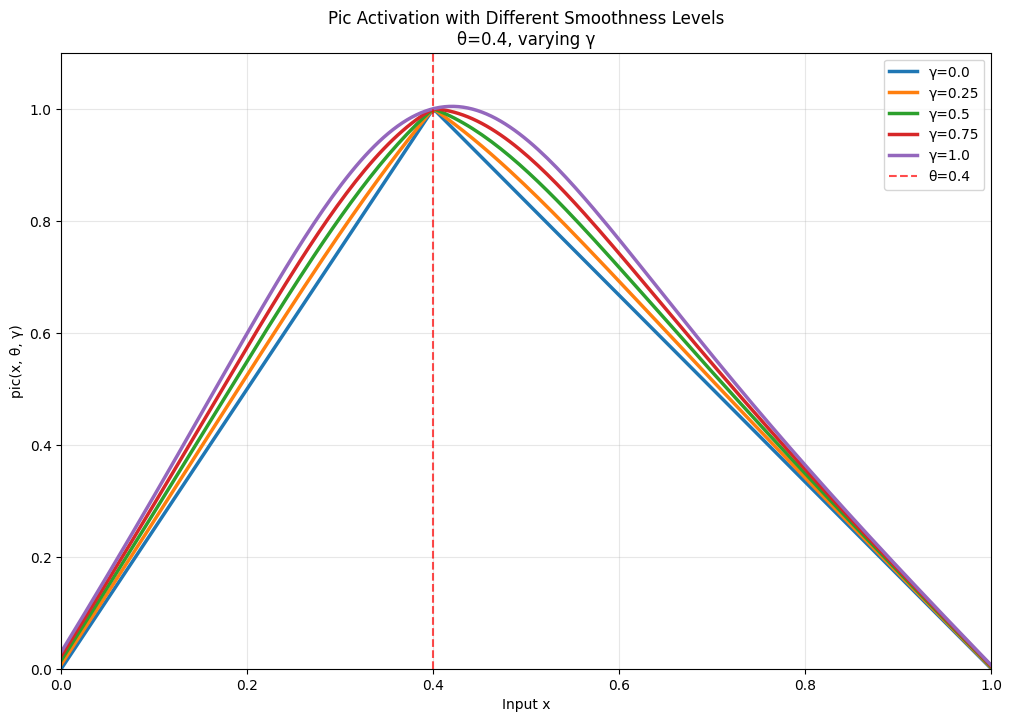

Smoothness Analysis:
γ=0.0: Sharp piecewise linear (non-differentiable at θ)
γ=1.0: Fully smooth (differentiable everywhere)
γ∈(0,1): Blended version with intermediate smoothness


In [12]:
# Test different gamma (smoothness) values
gamma_values = [0.0, 0.25, 0.5, 0.75, 1.0]
x_smooth = np.linspace(0, 1, 200).reshape(-1, 1)

plt.figure(figsize=(12, 8))

for gamma in gamma_values:
    pic_layer = Pic(theta_init=0.4, gamma=gamma)
    y_smooth = pic_layer.forward(x_smooth)
    
    plt.plot(x_smooth.flatten(), y_smooth.flatten(), 
            linewidth=2.5, label=f'γ={gamma}')

plt.axvline(x=0.4, color='red', linestyle='--', alpha=0.7, label='θ=0.4')
plt.title('Pic Activation with Different Smoothness Levels\nθ=0.4, varying γ')
plt.xlabel('Input x')
plt.ylabel('pic(x, θ, γ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1.1)
plt.show()

print("Smoothness Analysis:")
print("γ=0.0: Sharp piecewise linear (non-differentiable at θ)")
print("γ=1.0: Fully smooth (differentiable everywhere)")
print("γ∈(0,1): Blended version with intermediate smoothness")

In [13]:
# Test gradient check for different configurations
test_cases = [
    {"theta_init": 0.3, "gamma": 0.0, "name": "Piecewise Linear"},
    {"theta_init": 0.7, "gamma": 1.0, "name": "Smooth"},
    {"theta_init": 0.5, "gamma": 0.5, "name": "Blended"}
]

for case in test_cases:
    print(f"\nTesting {case['name']} (θ={case['theta_init']}, γ={case['gamma']}):")
    print("-" * 50)
    
    # Create Pic layer
    pic_layer = Pic(theta_init=case['theta_init'], gamma=case['gamma'])
    pic_layer.initialize(He(), Zero())
    
    # Generate random input in [0, 1] but away from boundaries
    np.random.seed(42)  # For reproducibility
    test_input = np.random.random((3, 2)) * 0.8 + 0.1  # Range [0.1, 0.9]
    
    print(f"  Initial θ value: {pic_layer.get_theta():.4f}")
    print(f"  Test input range: [{test_input.min():.3f}, {test_input.max():.3f}]")
    
    try:
        # Perform gradient check using our enhanced function
        result = gradient_check_layer(pic_layer, test_input, seed=42)  #Small differences (< 10%) are normal for complex smooth functions
        if result:
            print("  ✓ Gradient check PASSED")
        else:
            print("  ⚠ Gradient check completed with warnings")
    except Exception as e:
        print(f"  ✗ Gradient check ERROR: {e}")
    
    print(f"  Trainable: {pic_layer.trainable}")
    # print(f"  Parameters count: {pic_layer.get_params_count()}") # 1


Testing Piecewise Linear (θ=0.3, γ=0.0):
--------------------------------------------------
  Initial θ value: 0.4420
  Test input range: [0.225, 0.861]
    Theta gradient: analytical=0.849307, numerical=0.850461
    Theta rel_diff=0.000679 (tolerance=0.010)
    Input gradient: max_rel_diff=0.000000 (tolerance=0.010)
  ✓ Gradient check PASSED
  Trainable: True

Testing Smooth (θ=0.7, γ=1.0):
--------------------------------------------------
  Initial θ value: 0.8909
  Test input range: [0.225, 0.861]
    Theta gradient: analytical=2.916781, numerical=2.920742
    Theta rel_diff=0.000679 (tolerance=0.010)
    Input gradient: max_rel_diff=0.000000 (tolerance=0.010)
  ✓ Gradient check PASSED
  Trainable: True

Testing Blended (θ=0.5, γ=0.5):
--------------------------------------------------
  Initial θ value: 0.8909
  Test input range: [0.225, 0.861]
    Theta gradient: analytical=0.270074, numerical=0.270441
    Theta rel_diff=0.000679 (tolerance=0.010)
    Input gradient: max_rel_dif

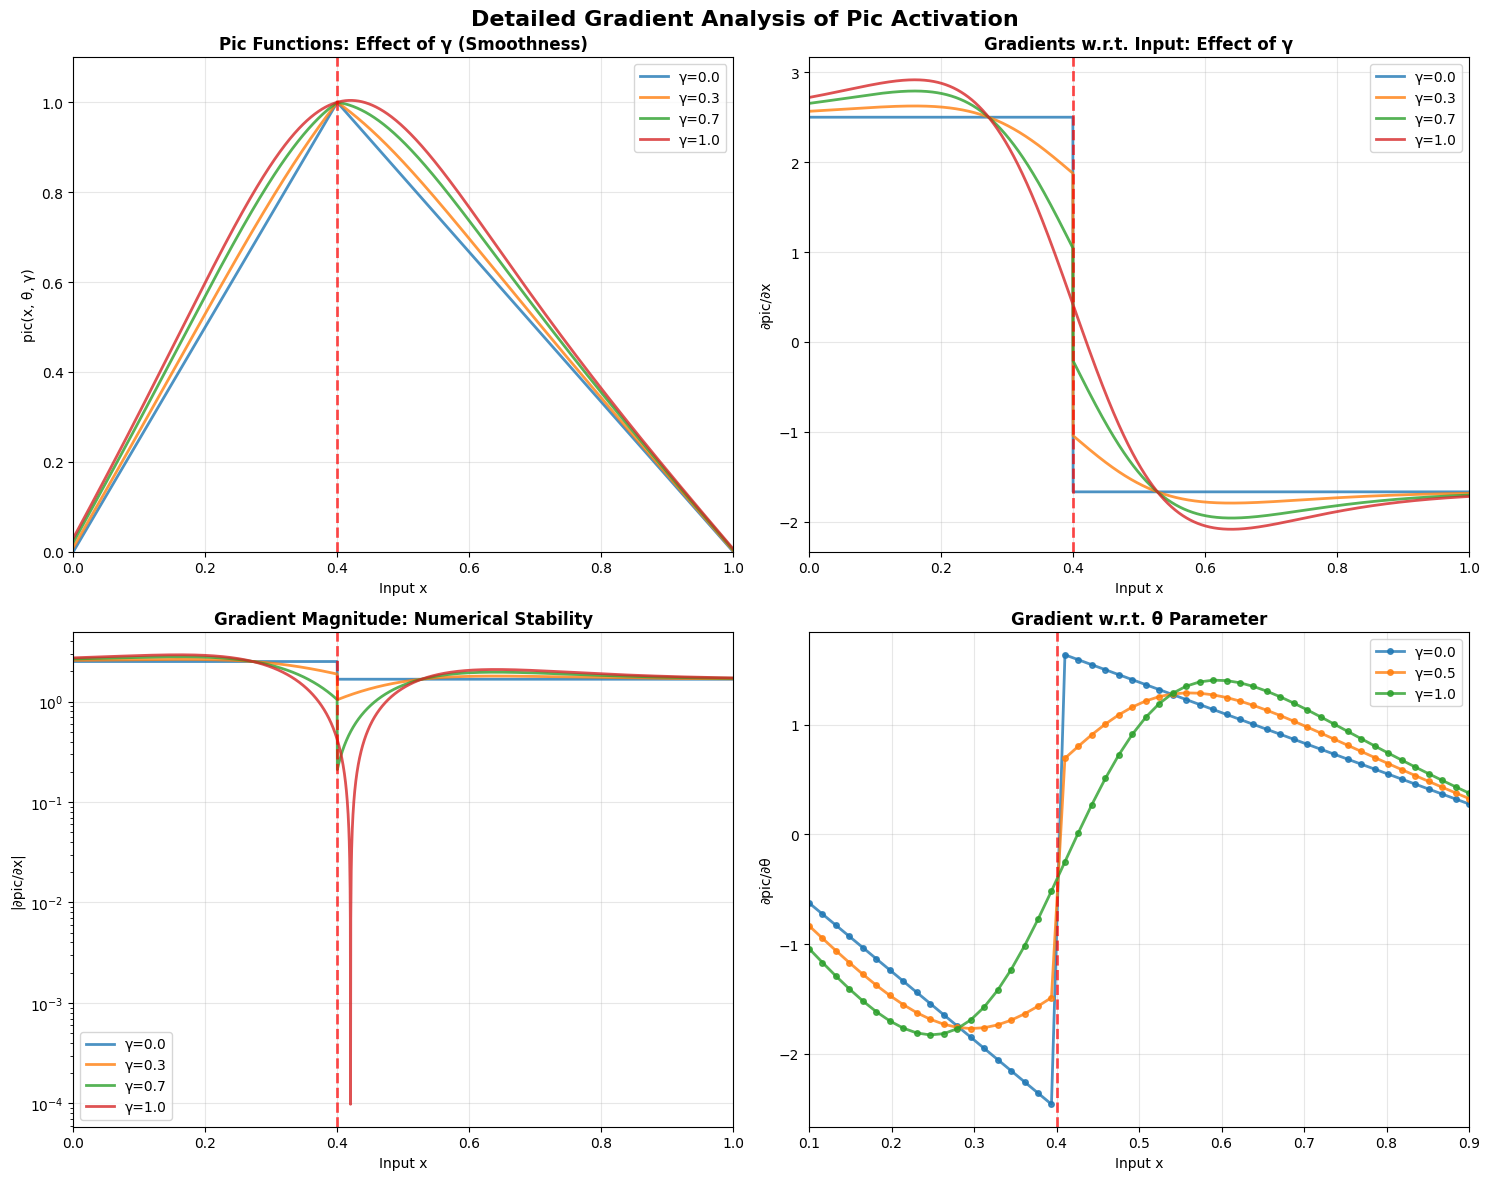

In [14]:
# Detailed gradient analysis plot
fig2, axes2 = plt.subplots(2, 2, figsize=(15, 12))
fig2.suptitle('Detailed Gradient Analysis of Pic Activation', fontsize=16, fontweight='bold')

# Compare gradients for different smoothness levels
x_fine = np.linspace(0, 1, 3000)
theta_test = 0.4
gamma_test_values = [0.0, 0.3, 0.7, 1.0]

# Plot 1: Activation functions with different gamma
for gamma in gamma_test_values:
    pic_layer = Pic(theta_init=theta_test, gamma=gamma)
    y = pic_layer.forward(x_fine.reshape(-1, 1))
    axes2[0, 0].plot(x_fine, y.flatten(), linewidth=2, 
                    label=f'γ={gamma}', alpha=0.8)

axes2[0, 0].axvline(x=theta_test, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes2[0, 0].set_title('Pic Functions: Effect of γ (Smoothness)', fontweight='bold')
axes2[0, 0].set_xlabel('Input x')
axes2[0, 0].set_ylabel('pic(x, θ, γ)')
axes2[0, 0].grid(True, alpha=0.3)
axes2[0, 0].legend()
axes2[0, 0].set_xlim(0, 1)
axes2[0, 0].set_ylim(0, 1.1)

# Plot 2: Corresponding gradients
for gamma in gamma_test_values:
    pic_layer = Pic(theta_init=theta_test, gamma=gamma)
    
    # Forward pass to set up the layer state
    x_tensor = x_fine.reshape(-1, 1)
    pic_layer.forward(x_tensor.copy())
    
    # Compute gradients using the layer's backward method
    error_tensor = np.ones_like(x_tensor)  # Unity error to get pure gradients
    grad_input = pic_layer.backward(error_tensor)
    
    axes2[0, 1].plot(x_fine, grad_input.flatten(), linewidth=2, 
                    label=f'γ={gamma}', alpha=0.8)

axes2[0, 1].axvline(x=theta_test, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes2[0, 1].set_title('Gradients w.r.t. Input: Effect of γ', fontweight='bold')
axes2[0, 1].set_xlabel('Input x')
axes2[0, 1].set_ylabel('∂pic/∂x')
axes2[0, 1].grid(True, alpha=0.3)
axes2[0, 1].legend()
axes2[0, 1].set_xlim(0, 1)

# Plot 3: Gradient magnitude (for numerical stability analysis)
for gamma in gamma_test_values:
    pic_layer = Pic(theta_init=theta_test, gamma=gamma)
    x_tensor = x_fine.reshape(-1, 1)
    pic_layer.forward(x_tensor.copy())
    error_tensor = np.ones_like(x_tensor)
    grad_input = pic_layer.backward(error_tensor)
    
    axes2[1, 0].plot(x_fine, np.abs(grad_input.flatten()), linewidth=2, 
                    label=f'γ={gamma}', alpha=0.8)

axes2[1, 0].axvline(x=theta_test, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes2[1, 0].set_title('Gradient Magnitude: Numerical Stability', fontweight='bold')
axes2[1, 0].set_xlabel('Input x')
axes2[1, 0].set_ylabel('|∂pic/∂x|')
axes2[1, 0].grid(True, alpha=0.3)
axes2[1, 0].legend()
axes2[1, 0].set_xlim(0, 1)
axes2[1, 0].set_yscale('log')

# Plot 4: Gradient of theta parameter across different input points
x_sample = np.linspace(0.1, 0.9, 50)
theta_grads = {}

for gamma in [0.0, 0.5, 1.0]:
    grad_theta_values = []
    
    for x_val in x_sample:
        pic_layer = Pic(theta_init=theta_test, gamma=gamma)
        x_tensor = np.array([[x_val]])
        pic_layer.forward(x_tensor.copy())
        error_tensor = np.ones_like(x_tensor)
        pic_layer.backward(error_tensor)
        
        # Extract theta gradient for this input
        grad_theta_values.append(pic_layer.gradient_weights)
    
    theta_grads[gamma] = grad_theta_values
    axes2[1, 1].plot(x_sample, grad_theta_values, 'o-', linewidth=2, 
                    label=f'γ={gamma}', alpha=0.8, markersize=4)

axes2[1, 1].axvline(x=theta_test, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes2[1, 1].set_title('Gradient w.r.t. θ Parameter', fontweight='bold')
axes2[1, 1].set_xlabel('Input x')
axes2[1, 1].set_ylabel('∂pic/∂θ')
axes2[1, 1].grid(True, alpha=0.3)
axes2[1, 1].legend()
axes2[1, 1].set_xlim(0.1, 0.9)

plt.tight_layout()
plt.show()

Training data: (1000, 1), Target data: (1000, 1)
Test data: (200, 1), Target data: (200, 1)


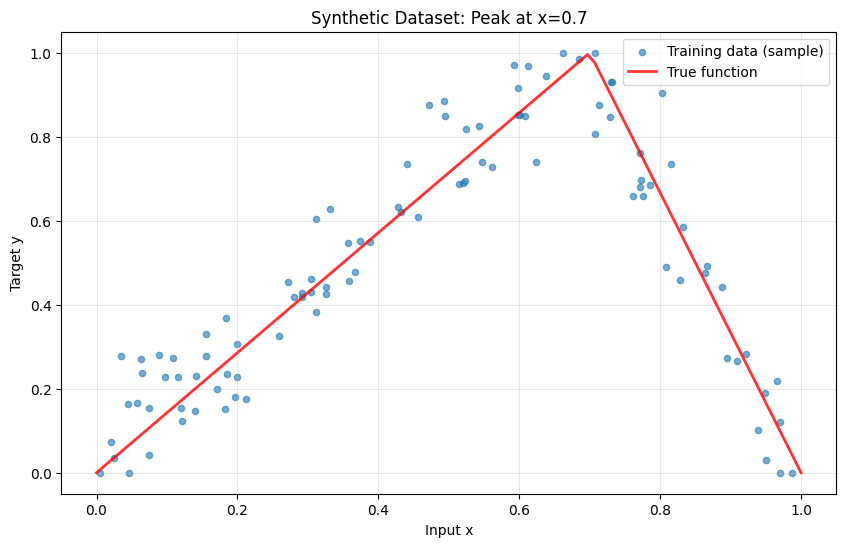

✓ Synthetic data created successfully!
Target peak at x=0.7, function is pic-like
Data range: X ∈ [0,1], y ∈ [0,1] with noise


In [15]:
# Create synthetic regression problem
def create_synthetic_data(n_samples=1000, target_peak=0.7, noise_level=0.1):
    """
    Create synthetic data where the target has a peak at target_peak.
    """
    X = np.random.random((n_samples, 1))  # Input in [0, 1]
    
    # Target function: pic-like with peak at target_peak
    y = np.where(
        X <= target_peak,
        X / target_peak,
        (1 - X) / (1 - target_peak)
    )
    
    # Add some noise
    y += np.random.normal(0, noise_level, y.shape)
    y = np.clip(y, 0, 1)  # Keep in [0, 1]
    
    return X, y

# Generate data
np.random.seed(42)  # For reproducibility
X_train, y_train = create_synthetic_data(n_samples=1000, target_peak=0.7)
X_test, y_test = create_synthetic_data(n_samples=200, target_peak=0.7)

print(f"Training data: {X_train.shape}, Target data: {y_train.shape}")
print(f"Test data: {X_test.shape}, Target data: {y_test.shape}")

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:100], y_train[:100], alpha=0.6, label='Training data (sample)', s=20)
plt.xlabel('Input x')
plt.ylabel('Target y')
plt.title('Synthetic Dataset: Peak at x=0.7')
plt.grid(True, alpha=0.3)
plt.legend()

# Add the true function for reference
x_true = np.linspace(0, 1, 100)
y_true = np.where(x_true <= 0.7, x_true / 0.7, (1 - x_true) / (1 - 0.7))
plt.plot(x_true, y_true, 'r-', linewidth=2, label='True function', alpha=0.8)
plt.legend()
plt.show()

print("✓ Synthetic data created successfully!")
print(f"Target peak at x=0.7, function is pic-like")
print(f"Data range: X ∈ [0,1], y ∈ [0,1] with noise")

In [16]:
class SimpleRegressionData:
    def __init__(self, X, y, batch_size=32):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.n_samples = X.shape[0]
        self.current_index = 0
        
    def next(self):
        """Get next batch of data"""
        if self.current_index >= self.n_samples:
            self.current_index = 0
            # Shuffle data
            indices = np.random.permutation(self.n_samples)
            self.X = self.X[indices]
            self.y = self.y[indices]
        
        end_index = min(self.current_index + self.batch_size, self.n_samples)
        batch_X = self.X[self.current_index:end_index]
        batch_y = self.y[self.current_index:end_index]
        
        self.current_index = end_index
        
        return batch_X, batch_y

# Create data layer
data_layer = SimpleRegressionData(X_train, y_train, batch_size=32)

# Test the data layer
test_batch_X, test_batch_y = data_layer.next()
print(f"Sample batch: X shape {test_batch_X.shape}, y shape {test_batch_y.shape}")
print(f"X range: [{test_batch_X.min():.3f}, {test_batch_X.max():.3f}]")
print(f"y range: [{test_batch_y.min():.3f}, {test_batch_y.max():.3f}]")

Sample batch: X shape (32, 1), y shape (32, 1)
X range: [0.021, 0.970]
y range: [0.000, 0.972]


In [17]:
def create_simple_network(activation_layer, input_size=1, hidden_size=1, output_size=1):
    """Create a simple 2-layer network with specified activation"""
    net = NeuralNetwork(
        optimizer=Adam(learning_rate=0.01),
        weights_initializer=He(),
        bias_initializer=Zero()
    )
    
    # Add layers
    net.append_layer(FullyConnected(input_size, hidden_size))
    net.append_layer(activation_layer)
    net.append_layer(FullyConnected(hidden_size, output_size))
    
    # Set data and loss
    net.data_layer = data_layer
    net.loss_layer = L2Loss()
    
    return net

ReLU: 3 layers


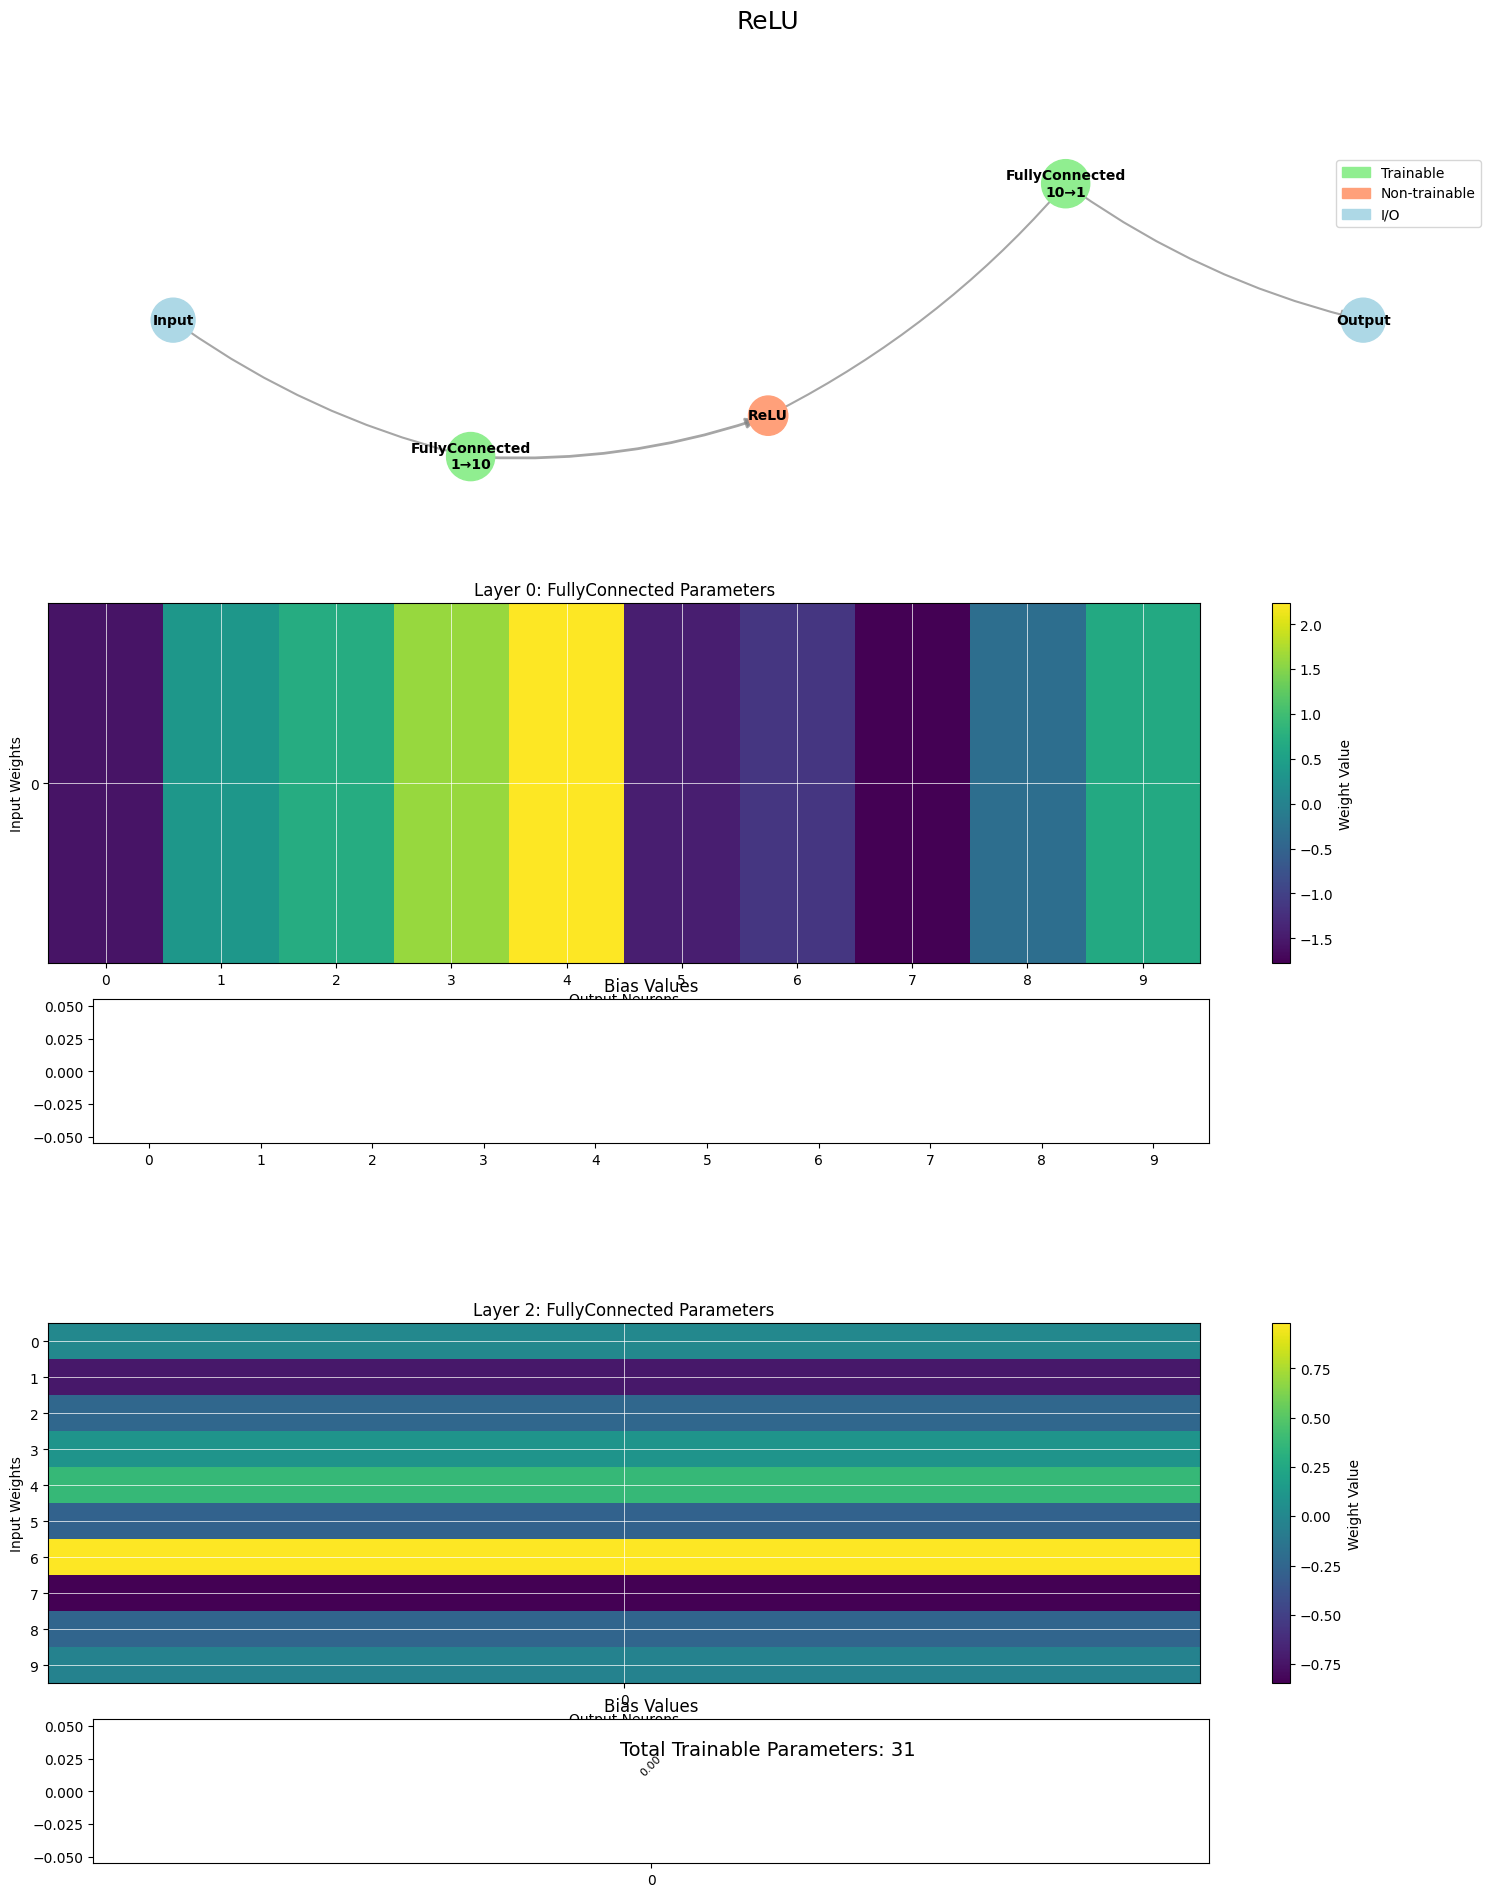

Pic_fixed_0.3: 3 layers
  Initial theta: 0.300, trainable: False


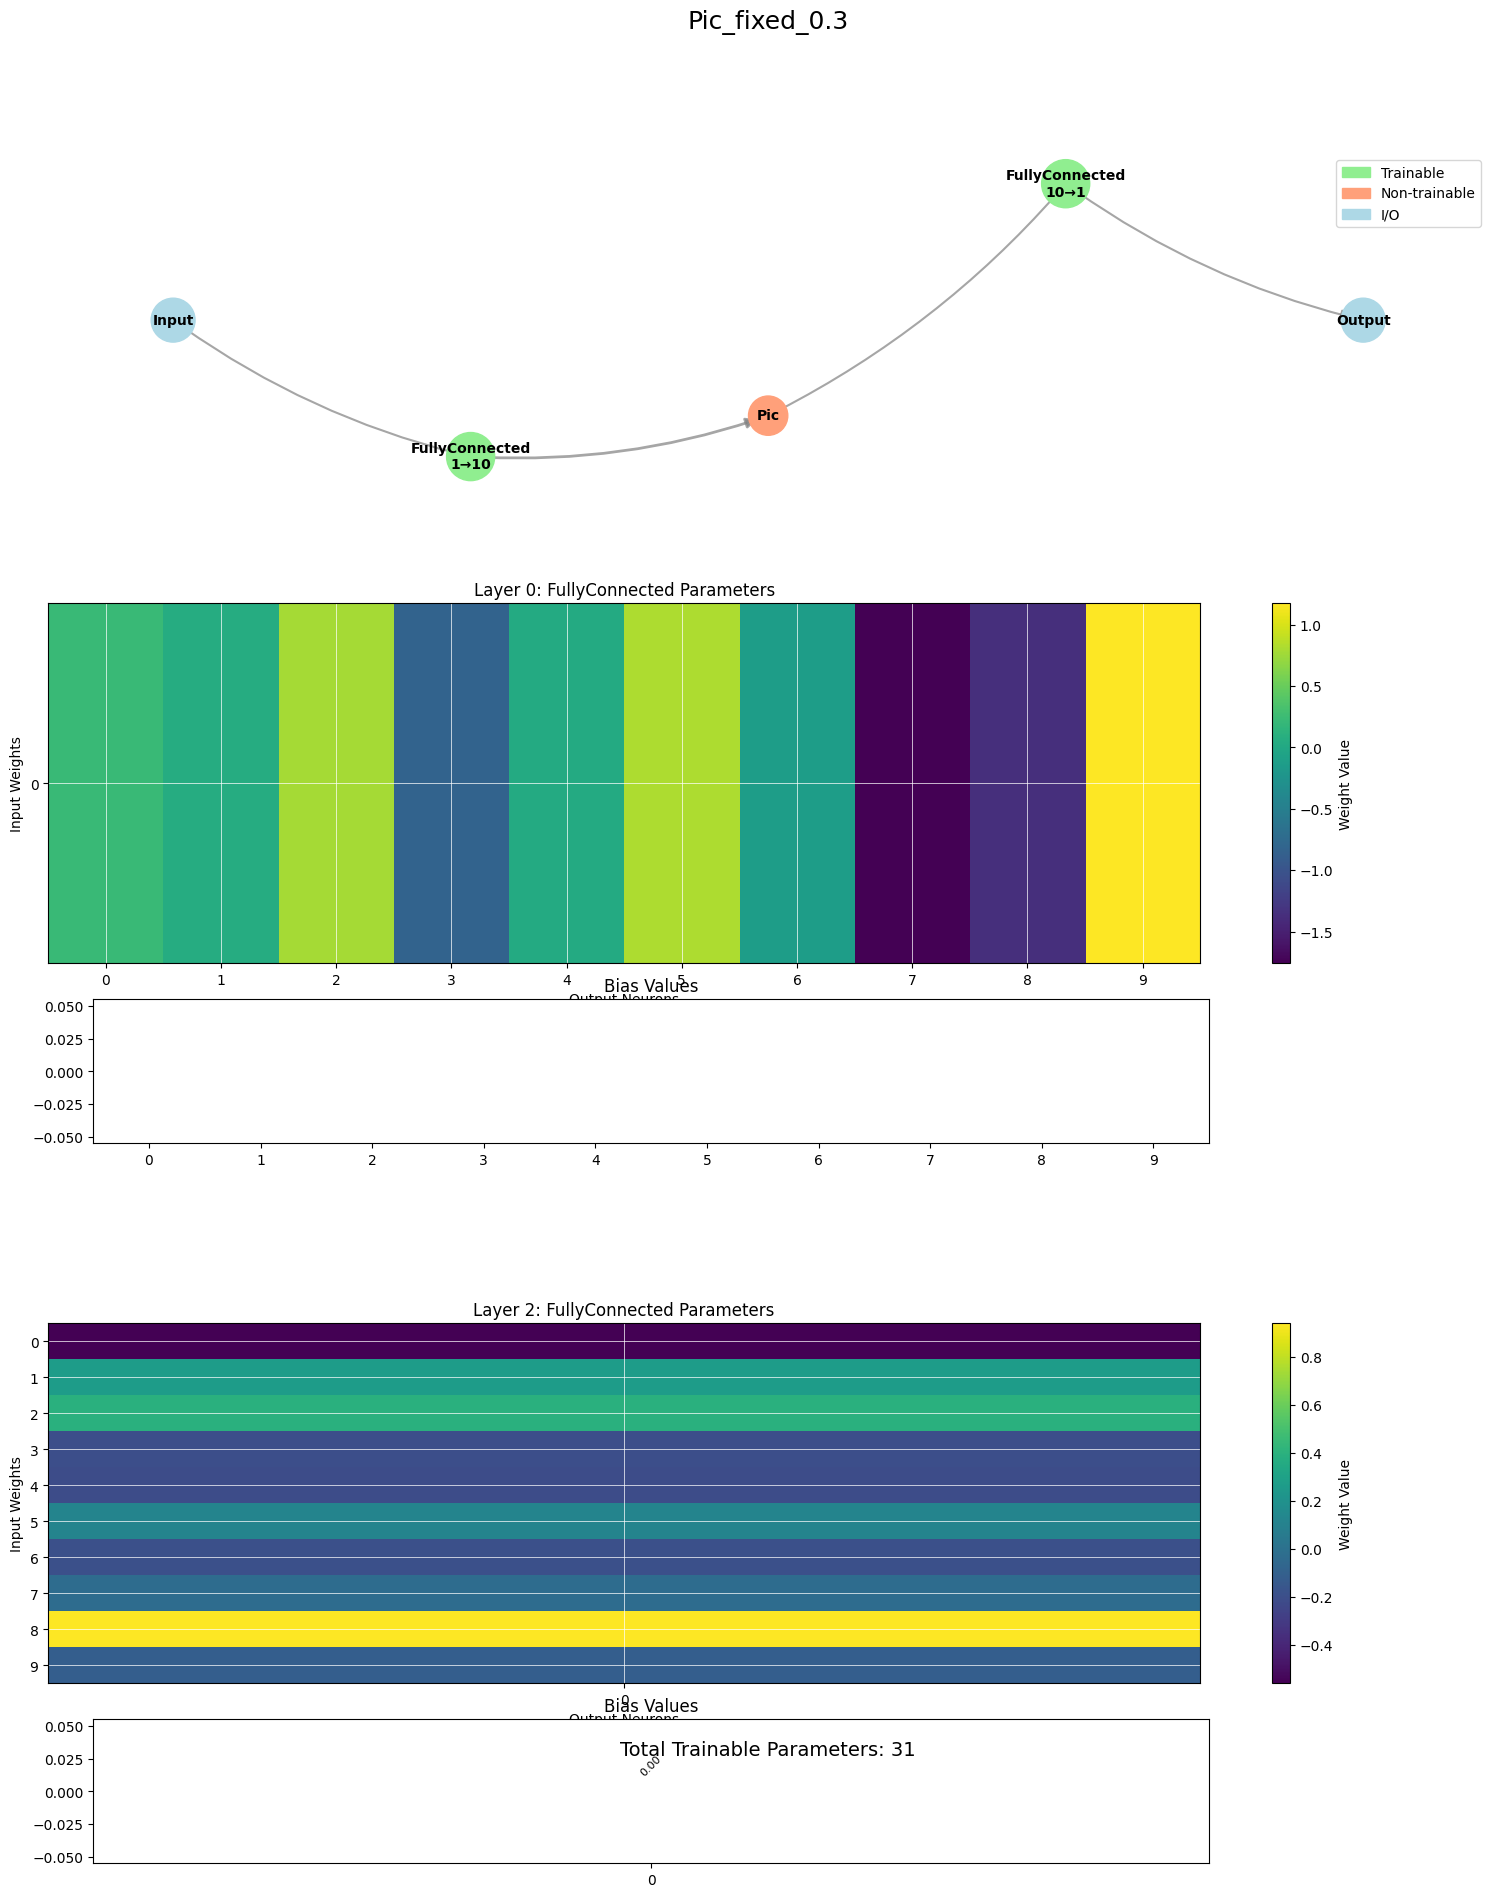

Pic_fixed_0.7: 3 layers
  Initial theta: 0.700, trainable: False


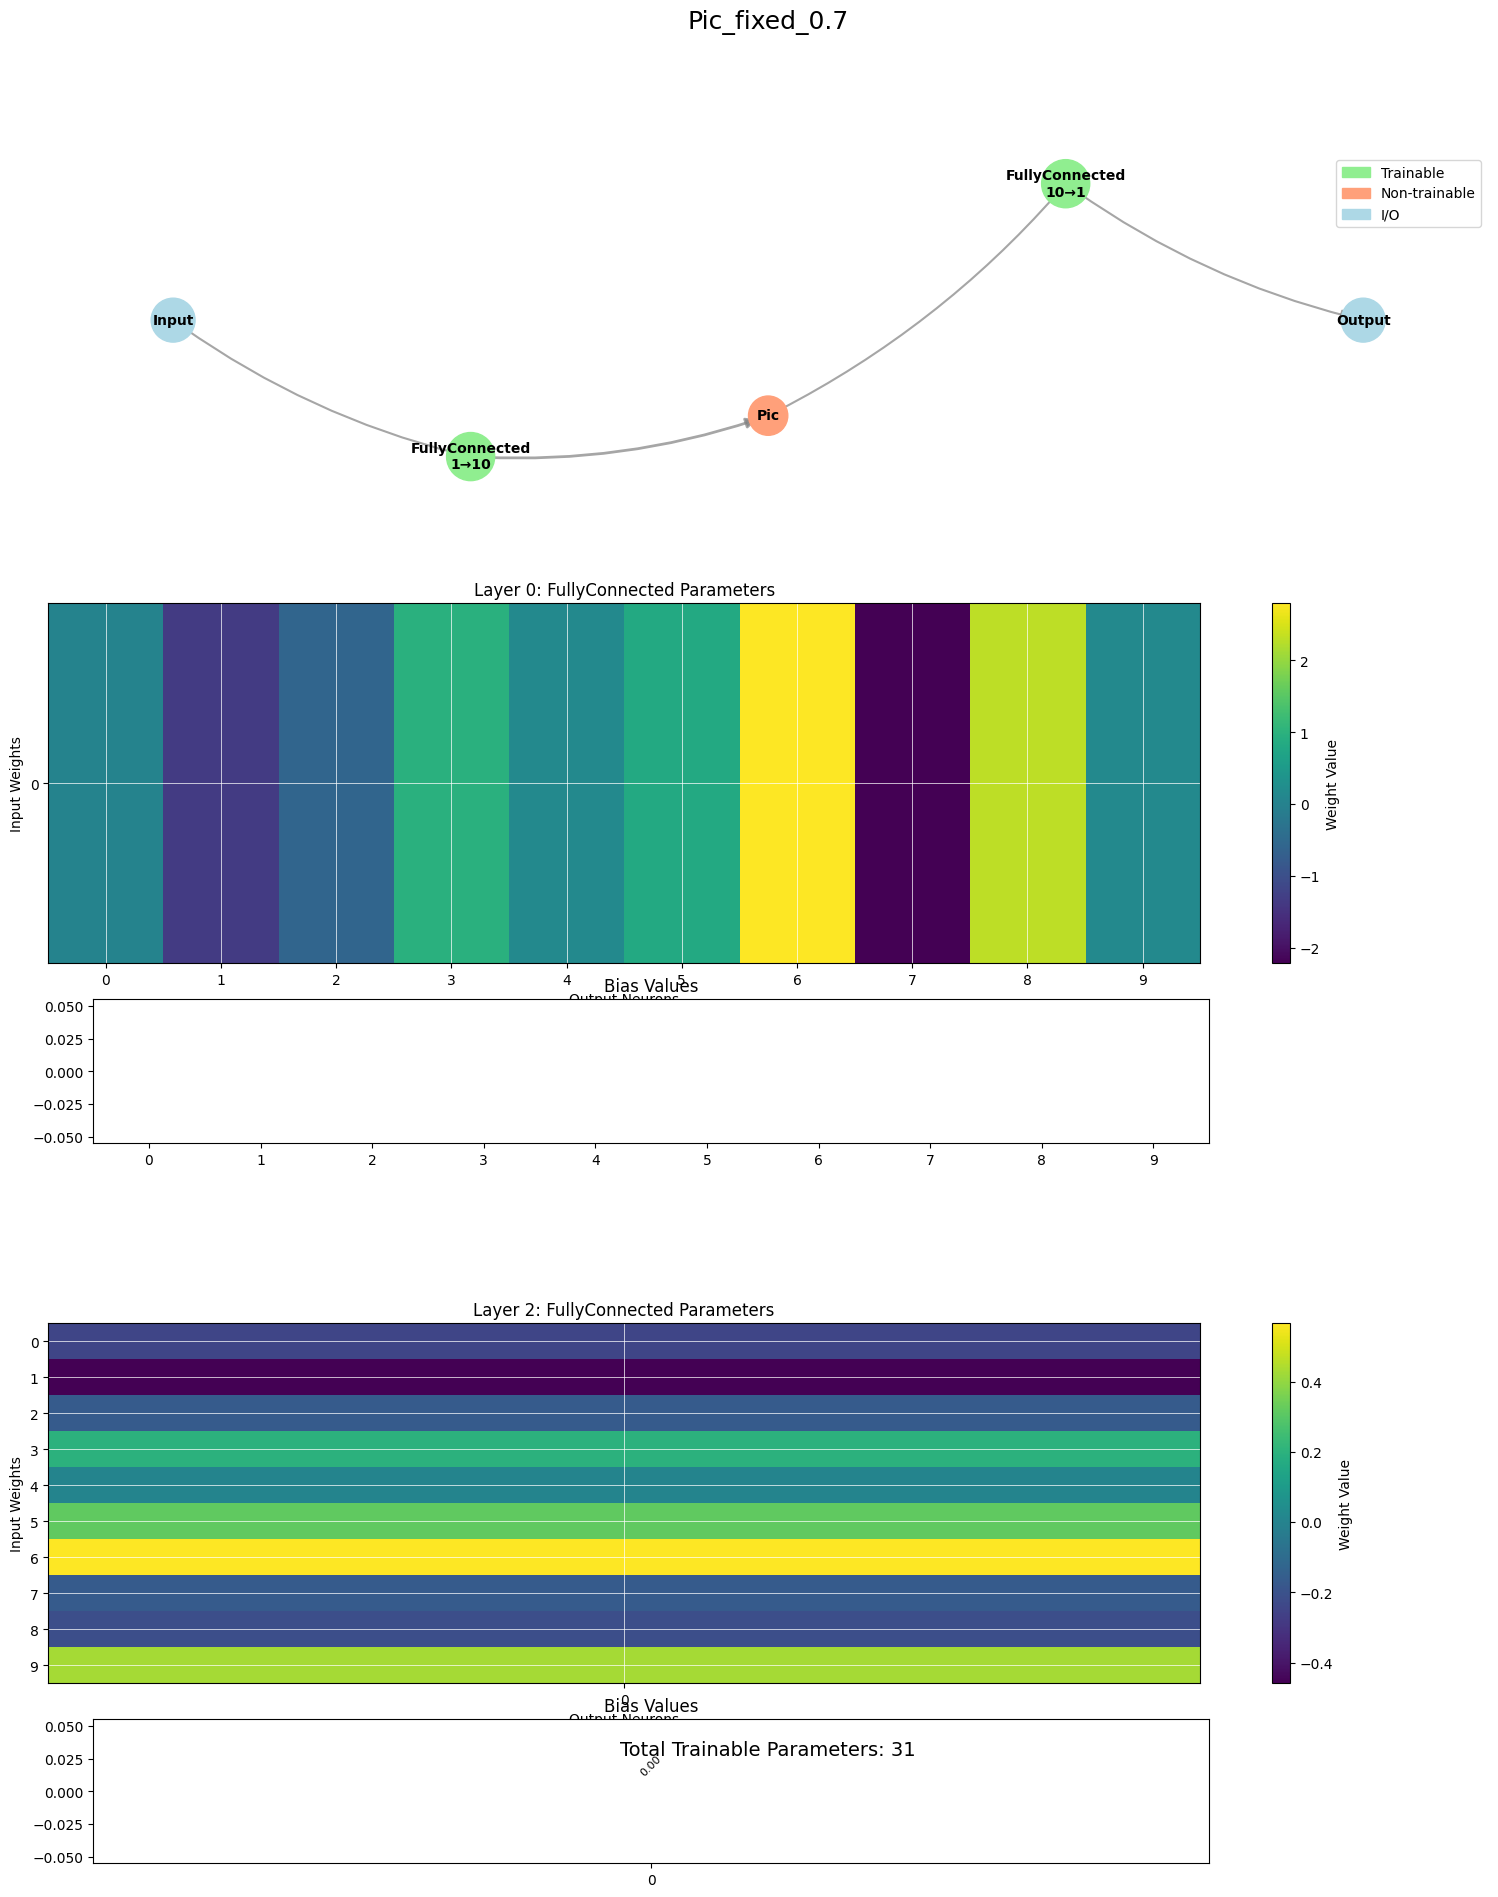

Pic_trainable: 3 layers
  Initial theta: 0.887, trainable: True


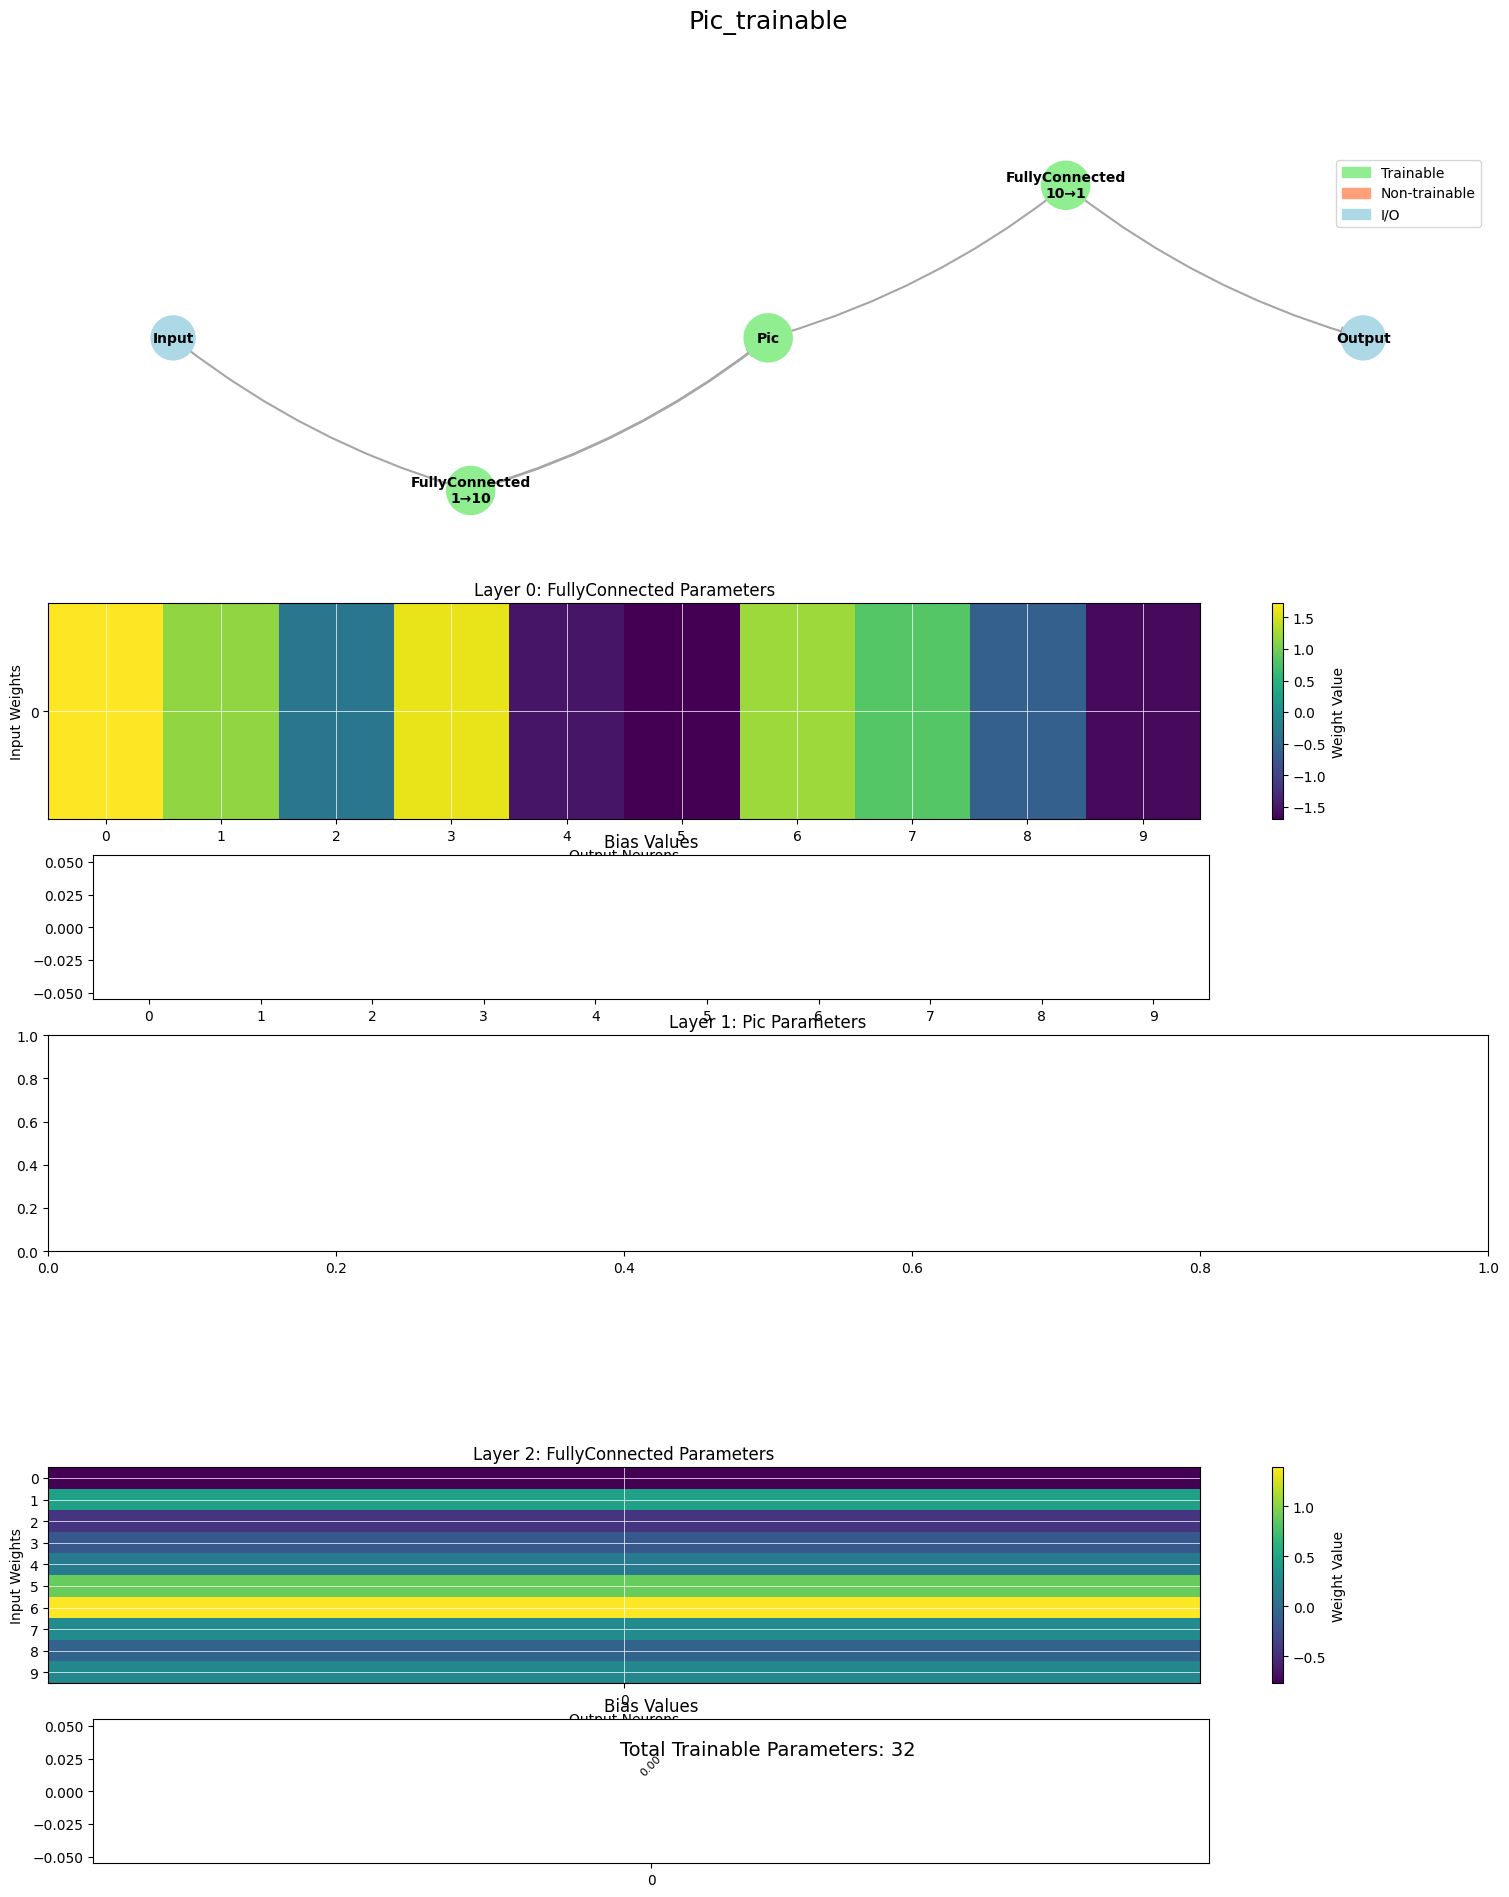

In [18]:
# Create different networks with proper trainable parameter handling
networks = {
    'ReLU': create_simple_network(ReLU(), hidden_size = 10),
    'Pic_fixed_0.3': create_simple_network(Pic(theta_init=0.3, gamma=0.0, trainable=False), hidden_size = 10),  # Set trainable=False at creation
    'Pic_fixed_0.7': create_simple_network(Pic(theta_init=0.7, gamma=0.0, trainable=False), hidden_size = 10),  # Set trainable=False at creation
    'Pic_trainable': create_simple_network(Pic(theta_init=0.5, gamma=0.0, trainable=True), hidden_size = 10)   # Explicitly set trainable=True
}

for name, net in networks.items():
    print(f"{name}: {len(net.layers)} layers")
    if 'Pic' in name:
        pic_layer = net.layers[1]  # Second layer is the activation
        print(f"  Initial theta: {pic_layer.get_theta():.3f}, trainable: {pic_layer.trainable}")
        
        # Verify the trainable setting is correct
        if 'fixed' in name and pic_layer.trainable:
            print(f"  WARNING: {name} should not be trainable but is set to trainable=True")
            # Fix it using the new method
            pic_layer.set_trainable(False)
            print(f"  FIXED: Set trainable=False, theta preserved at {pic_layer.get_theta():.3f}")
        elif 'trainable' in name and not pic_layer.trainable:
            print(f"  WARNING: {name} should be trainable but is set to trainable=False")
            
    net.plot(title=f"{name}")

In [19]:
# Train networks and track theta evolution
training_iterations = 2000
results = {}

print("Training networks...")
print("=" * 50)

for name, net in networks.items():
    print(f"\nTraining {name}...")
    
    # Track theta evolution for Pic layers
    theta_history = []
    loss_history = []
    
    # Reset data layer
    net.data_layer.current_index = 0
    
    for i in range(training_iterations):
        loss = net.forward()
        net.backward()
        
        loss_history.append(loss)
        
        # Track theta if it's a Pic layer
        if 'Pic' in name:
            pic_layer = net.layers[1]
            current_theta = pic_layer.get_theta()
            theta_history.append(current_theta)
            
            # For fixed layers, verify theta hasn't changed
            if 'fixed' in name and i > 0:
                if abs(current_theta - theta_history[0]) > 1e-6:
                    print(f"  ERROR: Fixed layer theta changed from {theta_history[0]:.6f} to {current_theta:.6f}")
        
        # Print progress
        if (i + 1) % 400 == 0:
            if 'Pic' in name:
                print(f"  Iteration {i+1}: Loss = {loss:.4f}, θ = {theta_history[-1]:.3f}")
            else:
                print(f"  Iteration {i+1}: Loss = {loss:.4f}")
    
    results[name] = {
        'loss_history': loss_history,
        'theta_history': theta_history,
        'final_loss': loss_history[-1],
        'network': net
    }
    
    if 'Pic' in name:
        pic_layer = net.layers[1]
        final_theta = pic_layer.get_theta()
        print(f"  Final θ: {final_theta:.3f}")
        
        # Verify fixed layers maintained their initial theta
        if 'fixed' in name:
            expected_theta = 0.3 if '0.3' in name else 0.7
            if abs(final_theta - expected_theta) > 1e-6:
                print(f"  ERROR: Expected θ={expected_theta:.3f}, got θ={final_theta:.3f}")
            else:
                print(f"  ✓ Fixed θ correctly maintained at {expected_theta:.3f}")

print("\nTraining completed!")

Training networks...

Training ReLU...
  Iteration 400: Loss = 0.2696
  Iteration 800: Loss = 0.0683
  Iteration 1200: Loss = 0.2776
  Iteration 1600: Loss = 0.1195
  Iteration 2000: Loss = 0.1635

Training Pic_fixed_0.3...
  Iteration 400: Loss = 0.5158, θ = 0.300
  Iteration 800: Loss = 0.1312, θ = 0.300
  Iteration 1200: Loss = 0.3990, θ = 0.300
  Iteration 1600: Loss = 0.1399, θ = 0.300
  Iteration 2000: Loss = 0.2823, θ = 0.300
  Final θ: 0.300
  ✓ Fixed θ correctly maintained at 0.300

Training Pic_fixed_0.7...
  Iteration 400: Loss = 0.5471, θ = 0.700
  Iteration 800: Loss = 0.0618, θ = 0.700
  Iteration 1200: Loss = 0.3084, θ = 0.700
  Iteration 1600: Loss = 0.0540, θ = 0.700
  Iteration 2000: Loss = 0.2699, θ = 0.700
  Final θ: 0.700
  ✓ Fixed θ correctly maintained at 0.700

Training Pic_trainable...
  Iteration 400: Loss = 0.4214, θ = 0.805
  Iteration 800: Loss = 0.0946, θ = 0.809
  Iteration 1200: Loss = 0.2098, θ = 0.825
  Iteration 1600: Loss = 0.0583, θ = 0.803
  Iterat

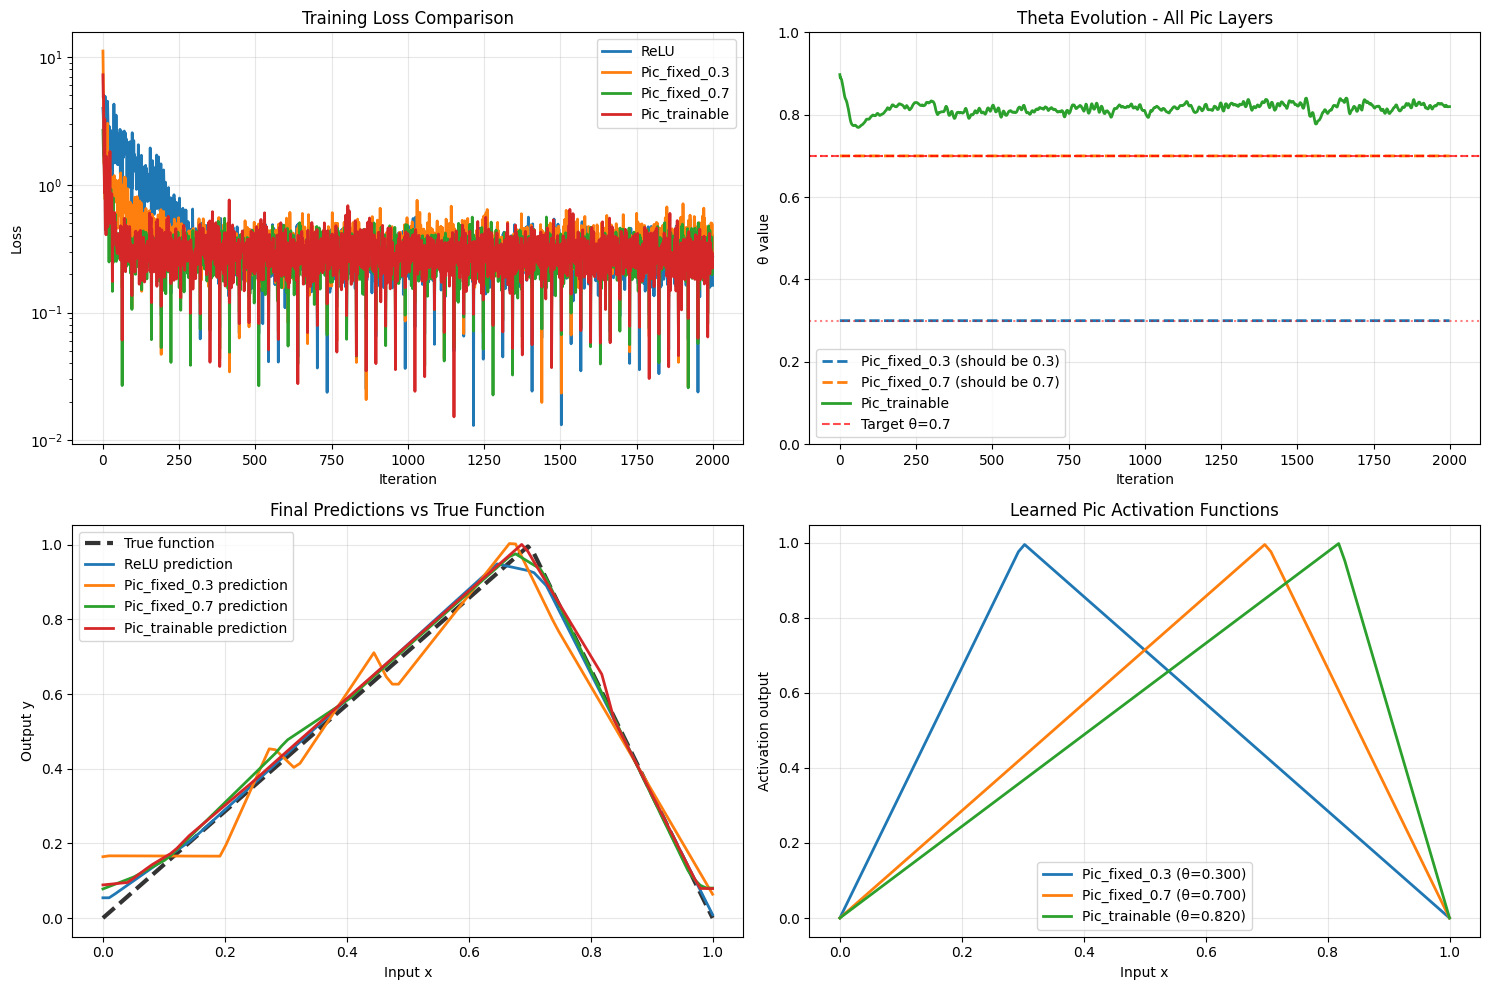

In [20]:
# Plot training results with enhanced verification
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Loss curves
for name, result in results.items():
    axes[0, 0].plot(result['loss_history'], label=name, linewidth=2)
axes[0, 0].set_title('Training Loss Comparison')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# Plot 2: Theta evolution for all Pic layers
for name, result in results.items():
    if 'Pic' in name and result['theta_history']:
        theta_hist = result['theta_history']
        if 'fixed' in name:
            # For fixed layers, show they should be constant
            expected_theta = 0.3 if '0.3' in name else 0.7
            axes[0, 1].plot(theta_hist, '--', linewidth=2, label=f'{name} (should be {expected_theta:.1f})')
            axes[0, 1].axhline(y=expected_theta, color='red', linestyle=':', alpha=0.5)
        else:
            # For trainable layer
            axes[0, 1].plot(theta_hist, '-', linewidth=2, label=f'{name}')

axes[0, 1].axhline(y=0.7, color='red', linestyle='--', label='Target θ=0.7', alpha=0.7)
axes[0, 1].set_title('Theta Evolution - All Pic Layers')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('θ value')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(0, 1)

# Plot 3: Final predictions comparison
x_eval = np.linspace(0, 1, 100).reshape(-1, 1)
y_true = np.where(x_eval <= 0.7, x_eval / 0.7, (1 - x_eval) / (1 - 0.7))

axes[1, 0].plot(x_eval, y_true, 'k--', linewidth=3, label='True function', alpha=0.8)

for name, result in results.items():
    net = result['network']
    y_pred = net.test(x_eval)
    axes[1, 0].plot(x_eval, y_pred, label=f'{name} prediction', linewidth=2)

axes[1, 0].set_title('Final Predictions vs True Function')
axes[1, 0].set_xlabel('Input x')
axes[1, 0].set_ylabel('Output y')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Learned activation functions
x_activation = np.linspace(0, 1, 100).reshape(-1, 1)

for name, result in results.items():
    if 'Pic' in name:
        net = result['network']
        pic_layer = net.layers[1]
        y_activation = pic_layer.forward(x_activation)
        
        # Get the actual theta value used in the activation
        actual_theta = pic_layer.get_theta()
        
        # Simply plot the activation function
        axes[1, 1].plot(x_activation, y_activation, 
                       label=f'{name} (θ={actual_theta:.3f})', 
                       linewidth=2)

axes[1, 1].set_title('Learned Pic Activation Functions')
axes[1, 1].set_xlabel('Input x')
axes[1, 1].set_ylabel('Activation output')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()